In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [3]:
df= pd.get_dummies(df, columns=['State'], drop_first=True)
df[['State_Florida', 'State_New York']] = \
df[['State_Florida', 'State_New York']].astype(int)

In [4]:
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0


In [5]:
print(df.shape)

(50, 6)


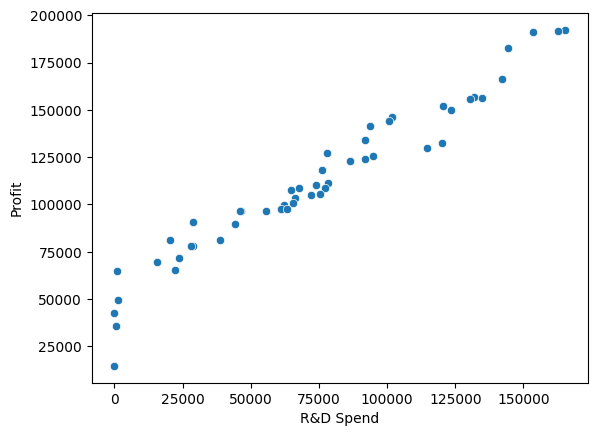

In [6]:
#R&D Spend vs Profit
sns.scatterplot(x='R&D Spend', y='Profit', data=df)
plt.show()

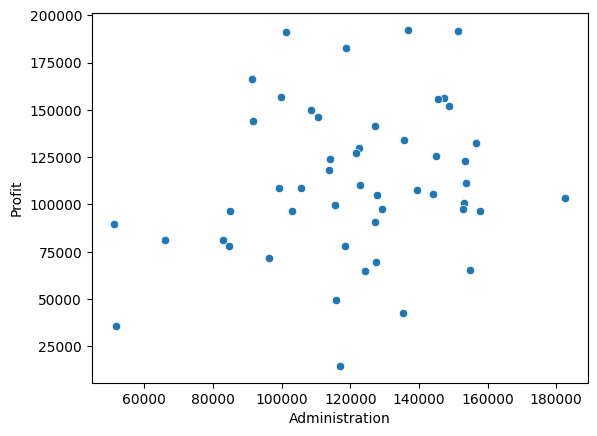

In [7]:
#Administration vs Profit
sns.scatterplot(x='Administration', y='Profit', data=df)
plt.show()

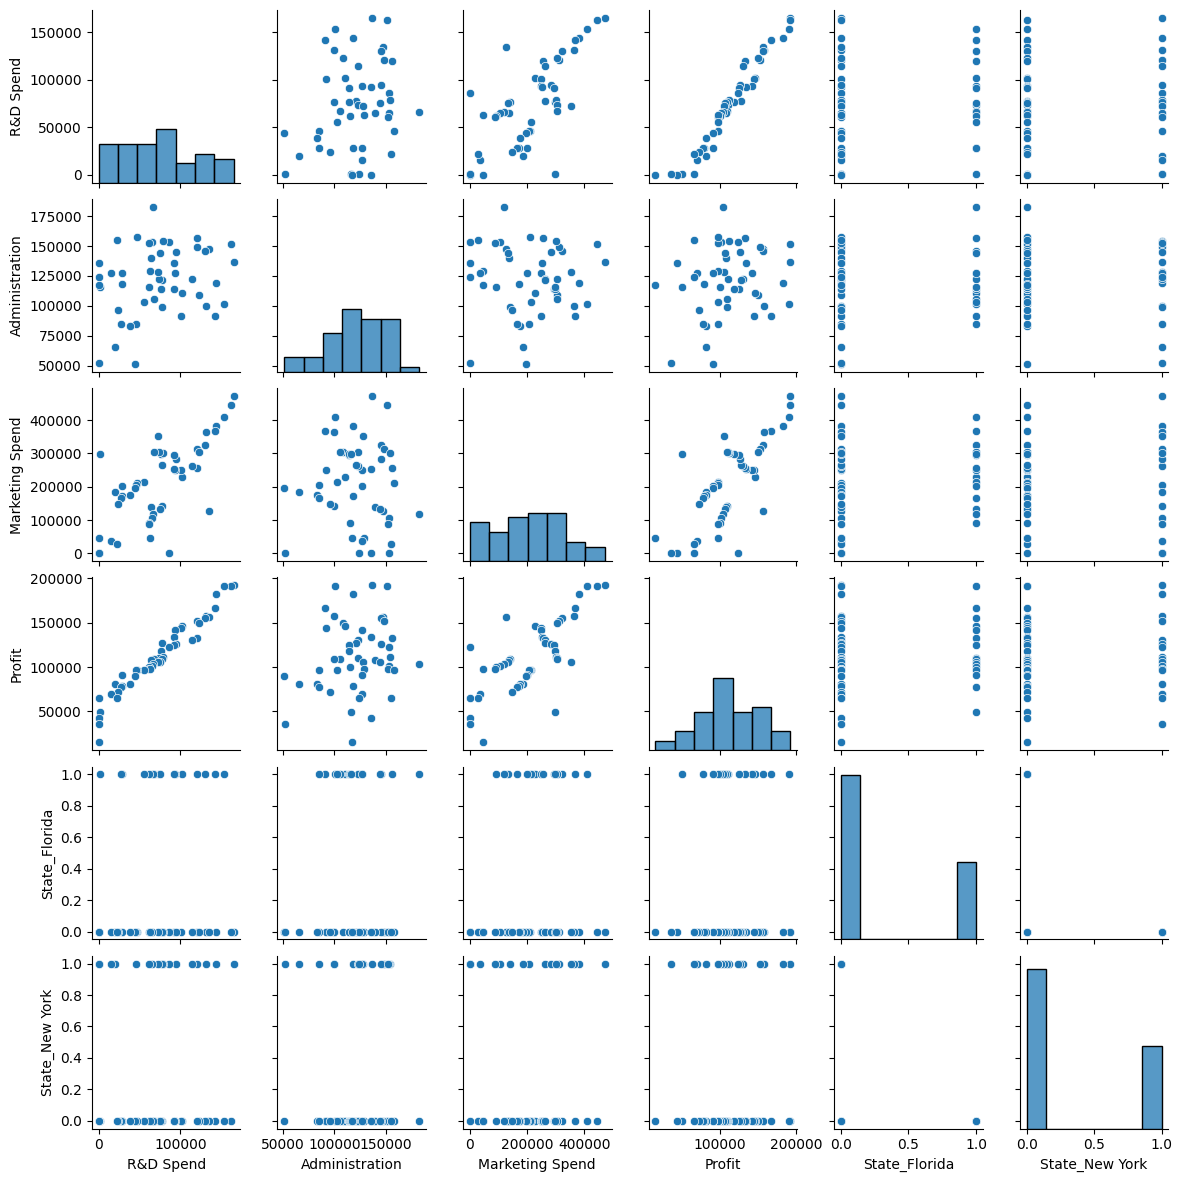

In [8]:
#Pairplot
sns.pairplot(data=df, height=2)

In [9]:
#Checking for multicollinearity using VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):
    vif = pd.DataFrame()
    vif["VIF"] = [variance_inflation_factor(X.values, i)
                    for i in range(X.shape[1])]
    vif.index = X.columns   #directly assign column names as index
    return vif              

In [10]:
X = df.drop('Profit', axis=1)
calc_vif(X)

,VIF
R&D Spend,8.451019
Administration,4.950277
Marketing Spend,8.092278
State_Florida,2.004519
State_New York,1.928836


In [11]:
x = df[['R&D Spend','Administration','Marketing Spend','State_Florida','State_New York']]
y = df['Profit']

In [12]:
x.head()

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0


In [13]:
#split X and Y into training and test data sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
#implementing the linear model
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
#model equation
print("Intercept:", regressor.intercept_)
print("Coefficients:", regressor.coef_)
list(zip(x, regressor.coef_))

Intercept: 54028.03959364583
Coefficients: [ 8.05630064e-01 -6.87878823e-02  2.98554429e-02  9.38793006e+02
  6.98775997e+00]


[('R&D Spend', np.float64(0.8056300637153668)),
 ('Administration', np.float64(-0.06878788227713242)),
 ('Marketing Spend', np.float64(0.02985544292263425)),
 ('State_Florida', np.float64(938.7930061484279)),
 ('State_New York', np.float64(6.987759966980904))]

In [16]:
#prediction of test set
y_pred_regressor=regressor.predict(X_test)
print("Prediction for test set: {}".format(y_pred_regressor))

Prediction for test set: [126362.87908255  84608.45383634  99677.49425147  46357.46068582
 128750.48288504  50912.4174188  109741.35032702 100643.24281647
  97599.27574594 113097.42524432]


In [17]:
#actual value and the predicted value
regressor_diff = pd.DataFrame({'Actual value': y_test, 'Predicted value': y_pred_regressor})
regressor_diff.head()

,Actual value,Predicted value
13,134307.35,126362.879083
39,81005.76,84608.453836
30,99937.59,99677.494251
45,64926.08,46357.460686
17,125370.37,128750.482885


In [18]:
#MODEL EVALUATION
from sklearn import metrics
mae=metrics.mean_absolute_error(y_test,y_pred_regressor)
mse=metrics.mean_squared_error(y_test,y_pred_regressor)
rmse=np.sqrt(metrics.mean_squared_error(y_test,y_pred_regressor))
print('R Squared:{:.2f}'.format(regressor.score(x,y)*100))
print('Mean Absolute Error:',mae)
print('Mean Square Error:',mse)
print('Root Mean Square Error:',rmse)

R Squared:94.96
Mean Absolute Error: 6961.477813252382
Mean Square Error: 82010363.04430111
Root Mean Square Error: 9055.957323458471


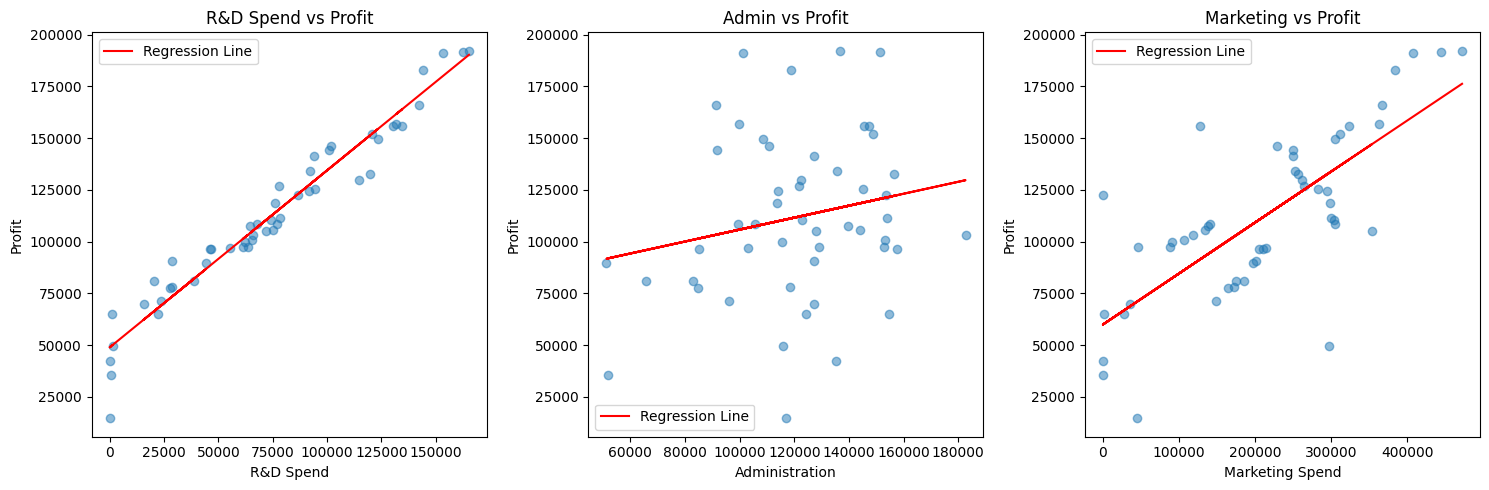

In [26]:
def plot_scatter_with_regression(ax, x_data, y_data, x_label, title):
    ax.scatter(x_data, y_data, alpha=0.5)
    slope, intercept = np.polyfit(x_data, y_data, 1)
    regression_line = slope * x_data + intercept
    ax.plot(x_data, regression_line, color='red', label='Regression Line')
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Profit')
    ax.legend()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_scatter_with_regression(axes[0], df['R&D Spend'], df['Profit'], 'R&D Spend', 'R&D Spend vs Profit')
plot_scatter_with_regression(axes[1], df['Administration'], df['Profit'], 'Administration', 'Admin vs Profit')
plot_scatter_with_regression(axes[2], df['Marketing Spend'], df['Profit'], 'Marketing Spend', 'Marketing vs Profit')

plt.tight_layout()
plt.show()